In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, roc_auc_score,
    precision_recall_curve, roc_curve)
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import shap

In [29]:
df=pd.read_csv('ai4i2020.csv')
display(df.shape)
display(df.head())

(10000, 14)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


dropping the id columns, and failure reasons to remove data leakage

In [30]:
drop_cols=['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
df_clean=df.drop(columns =drop_cols)

display("shape after dropping cols: ", df_clean.shape)
display(df_clean.head())

'shape after dropping cols: '

(10000, 7)

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


encoding type column to integers

In [31]:
le=LabelEncoder()
df_clean['Type']=le.fit_transform(df_clean['Type'])
display(df_clean['Type'].value_counts())
display(df_clean.head())

Type
1    6000
2    2997
0    1003
Name: count, dtype: int64

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,2,298.1,308.6,1551,42.8,0,0
1,1,298.2,308.7,1408,46.3,3,0
2,1,298.1,308.5,1498,49.4,5,0
3,1,298.2,308.6,1433,39.5,7,0
4,1,298.2,308.7,1408,40.0,9,0


defining x and y

In [32]:
X_full=df_clean.drop('Machine failure', axis=1)
y=df_clean['Machine failure']

print("X shape: ", X_full.shape)
print("y shape: ", y.shape)

print("\nTarget distribution:")
print(y.value_counts())
print(y.value_counts(normalize=True).mul(100).round(2))

X shape:  (10000, 6)
y shape:  (10000,)

Target distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


### train test split

80/20 split with stratify

In [33]:
X_train_full, X_test_full, y_train, y_test= train_test_split(X_full, y, test_size=0.2, stratify=y, random_state=42)

print("X_train_full:", X_train_full.shape)
print("X_test_full: ", X_test_full.shape)
print("y_train:     ", y_train.shape)
print("y_test:      ", y_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

X_train_full: (8000, 6)
X_test_full:  (2000, 6)
y_train:      (8000,)
y_test:       (2000,)

Train target distribution:
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

Test target distribution:
Machine failure
0    96.6
1     3.4
Name: proportion, dtype: float64


### smote- fixing class imabance

done only on training data. synthetic data point screated for minority class by interpolating between pre-existing minority class data points.

X_train_full and y_train_full will be used for baseline.

X_train_res and y_train_res will contain resampled values for main models

In [34]:
smote=SMOTE(random_state=42)
X_train_res, y_train_res= smote.fit_resample(X_train_full, y_train)

print("Before SMOTE:")
print(f"  X_train_full: {X_train_full.shape}")
print(f"  Failures: {y_train.sum()} ({y_train.mean()*100:.1f}%)")

print("\nAfter SMOTE:")
print(f"  X_train_res: {X_train_res.shape}")
print(f"  Failures: {y_train_res.sum()} ({y_train_res.mean()*100:.1f}%)")

Before SMOTE:
  X_train_full: (8000, 6)
  Failures: 271 (3.4%)

After SMOTE:
  X_train_res: (15458, 6)
  Failures: 7729 (50.0%)


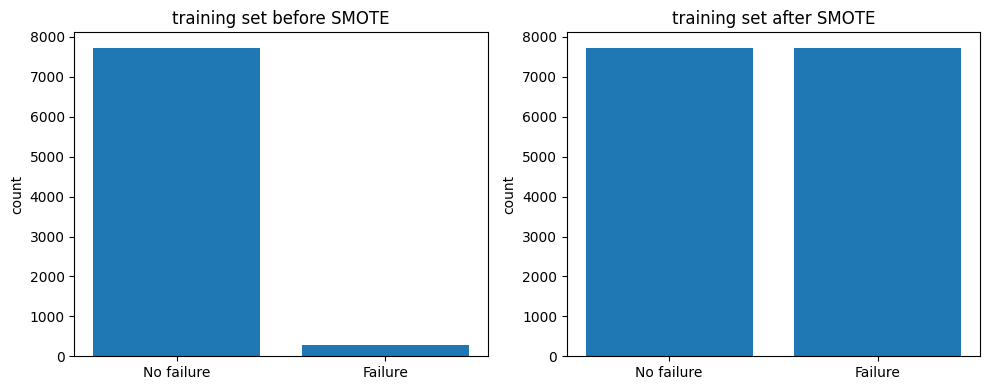

In [35]:
fig, axes= plt.subplots(1, 2, figsize=(10,4))

axes[0].bar(['No failure', 'Failure'], y_train.value_counts())
axes[0].set_title('training set before SMOTE')
axes[0].set_ylabel('count')

axes[1].bar(['No failure', 'Failure'], y_train_res.value_counts())
axes[1].set_title('training set after SMOTE')
axes[1].set_ylabel('count')

plt.tight_layout()
plt.show()

## baseline models:

on imbalanced data

In [36]:
results=[]

def evaluate_model(name, y_true, y_pred, y_prob):
    metrics = {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred) * 100, 1),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 3),
        'Recall':    round(recall_score(y_true, y_pred), 3),
        'F1':        round(f1_score(y_true, y_pred), 3),
        'ROC-AUC':   round(roc_auc_score(y_true, y_prob), 3),
    }
    results.append(metrics)

    print(f"\n  {name}")
    print(classification_report(y_true, y_pred, target_names=['No Failure', 'Failure']))
    return metrics

### model 1: dummy classifier

predicts onlt majority class


  Dummy Classifier
              precision    recall  f1-score   support

  No Failure       0.97      1.00      0.98      1932
     Failure       0.00      0.00      0.00        68

    accuracy                           0.97      2000
   macro avg       0.48      0.50      0.49      2000
weighted avg       0.93      0.97      0.95      2000



d:\Desktop\Manasvi\college\intern prep\predictive_maintenance\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Desktop\Manasvi\college\intern prep\predictive_maintenance\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Desktop\Manasvi\college\intern prep\predictive_maintenance\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to co

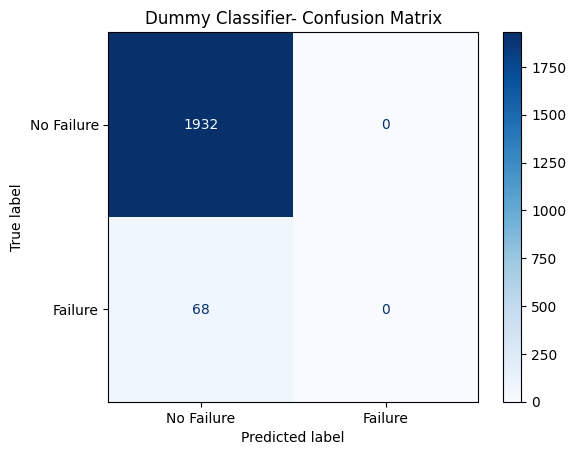

In [37]:
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_full, y_train)

y_pred_dummy = dummy.predict(X_test_full)
y_prob_dummy = dummy.predict_proba(X_test_full)[:, 1]

evaluate_model('Dummy Classifier', y_test, y_pred_dummy, y_prob_dummy)

cm = confusion_matrix(y_test, y_pred_dummy)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Failure', 'Failure'])
disp.plot(cmap='Blues')
plt.title('Dummy Classifier- Confusion Matrix')
plt.show()

shows why accuracy is very bad metric and need for smote

### model 2: logistic regression (without smote)


  Logistic Regression (no SMOTE)
              precision    recall  f1-score   support

  No Failure       0.97      1.00      0.98      1932
     Failure       0.60      0.13      0.22        68

    accuracy                           0.97      2000
   macro avg       0.79      0.56      0.60      2000
weighted avg       0.96      0.97      0.96      2000



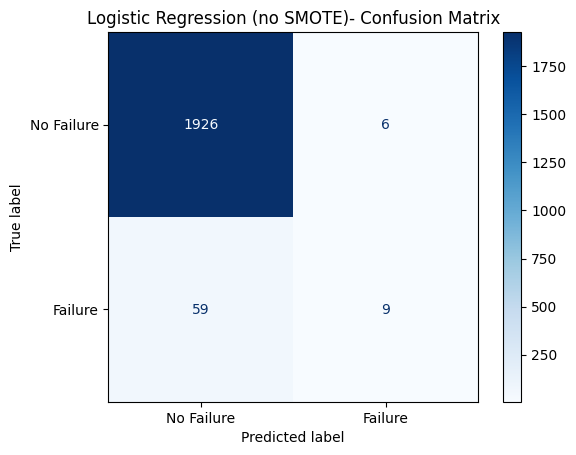

In [38]:
lr_base = LogisticRegression(max_iter=1000, random_state=42)
lr_base.fit(X_train_full, y_train)

y_pred_lr_base = lr_base.predict(X_test_full)
y_prob_lr_base = lr_base.predict_proba(X_test_full)[:, 1]

evaluate_model('Logistic Regression (no SMOTE)', y_test, y_pred_lr_base, y_prob_lr_base)

cm = confusion_matrix(y_test, y_pred_lr_base)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Failure', 'Failure'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression (no SMOTE)- Confusion Matrix')
plt.show()

without smote, there is some improvement from dummy (obviously)

### main models

using smote, decision trees

### model 3: logistic regression (using smote)

same model as before but trained on balanced data, showing effect of smote alone


  Logistic Regression (SMOTE)
              precision    recall  f1-score   support

  No Failure       0.99      0.85      0.91      1932
     Failure       0.15      0.79      0.26        68

    accuracy                           0.84      2000
   macro avg       0.57      0.82      0.58      2000
weighted avg       0.96      0.84      0.89      2000



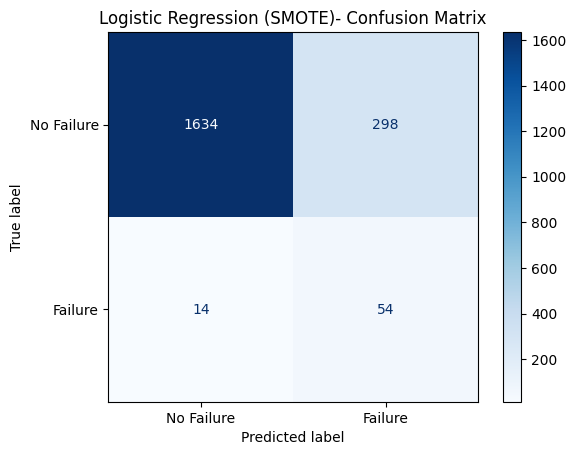

In [39]:
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_res, y_train_res)

y_pred_lr_smote = lr_smote.predict(X_test_full)
y_prob_lr_smote = lr_smote.predict_proba(X_test_full)[:, 1]

evaluate_model('Logistic Regression (SMOTE)', y_test, y_pred_lr_smote, y_prob_lr_smote)

cm = confusion_matrix(y_test, y_pred_lr_smote)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Failure', 'Failure'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression (SMOTE)- Confusion Matrix')
plt.show()

clear signifiacnt improvement in recall from unbalanced class. however, model fits a straight line, while the actual plot shows non-linearity. therefore decision tree based models will be used next.

### model 4: random forest (smote)

tree based model- will catch non-linearity


  Random Forest (SMOTE)
              precision    recall  f1-score   support

  No Failure       0.99      0.97      0.98      1932
     Failure       0.43      0.72      0.54        68

    accuracy                           0.96      2000
   macro avg       0.71      0.84      0.76      2000
weighted avg       0.97      0.96      0.96      2000



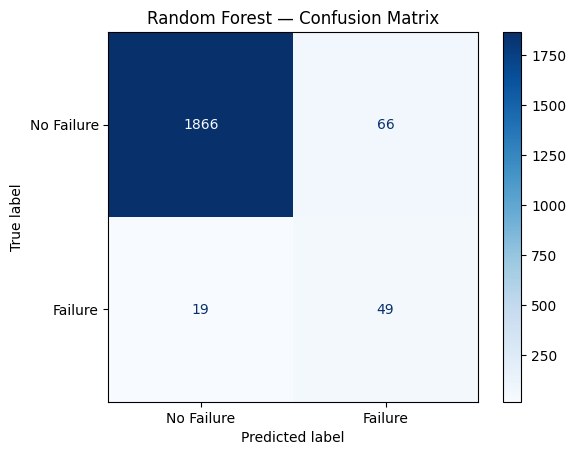

In [40]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test_full)
y_prob_rf = rf.predict_proba(X_test_full)[:, 1]

evaluate_model('Random Forest (SMOTE)', y_test, y_pred_rf, y_prob_rf)

cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Failure', 'Failure'])
disp.plot(cmap='Blues')
plt.title('Random Forest — Confusion Matrix')
plt.show()

### model 5: xgboost- default threshold(0.5)

should be stronger than random forest

In [41]:
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale:.1f}")

scale_pos_weight: 28.5



  XGBoost (threshold=0.5)
              precision    recall  f1-score   support

  No Failure       0.99      0.98      0.99      1932
     Failure       0.59      0.81      0.68        68

    accuracy                           0.97      2000
   macro avg       0.79      0.89      0.83      2000
weighted avg       0.98      0.97      0.98      2000



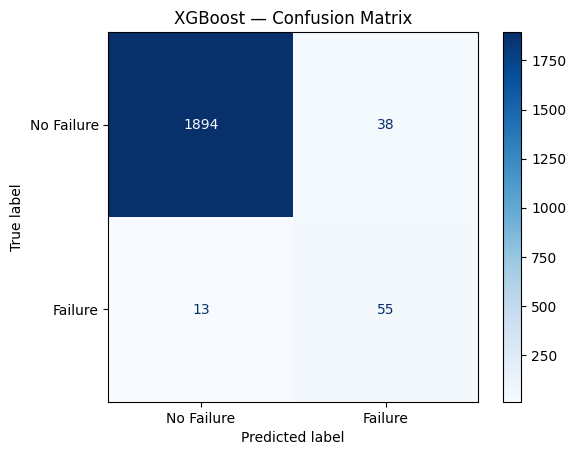

In [42]:
# XGBoost trained on original imbalanced data using scale_pos_weight
# instead of SMOTE — XGBoost handles imbalance natively this way

# Clean column names for XGBoost (doesn't allow [ ] or <)
X_train_xgb = X_train_full.copy()
X_test_xgb = X_test_full.copy()

clean_names = {col: col.replace('[', '').replace(']', '').replace('<', '').strip()
               for col in X_full.columns}

X_train_xgb = X_train_xgb.rename(columns=clean_names)
X_test_xgb = X_test_xgb.rename(columns=clean_names)

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    eval_metric='logloss',
    scale_pos_weight=scale,
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train_xgb, y_train)   # original imbalanced data, not X_train_res

y_prob_xgb = xgb.predict_proba(X_test_xgb)[:, 1]
y_pred_xgb_05 = (y_prob_xgb >= 0.5).astype(int)

evaluate_model('XGBoost (threshold=0.5)', y_test, y_pred_xgb_05, y_prob_xgb)

cm = confusion_matrix(y_test, y_pred_xgb_05)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Failure', 'Failure'])
disp.plot(cmap='Blues')
plt.title('XGBoost — Confusion Matrix')
plt.show()

## precision recall curve

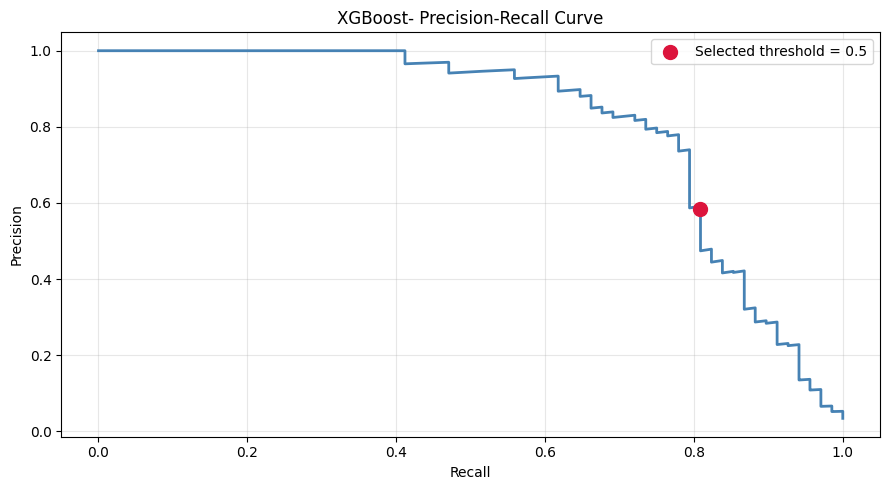

At threshold 0.5 → Precision: 0.585, Recall: 0.809


In [43]:
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_prob_xgb)

plt.figure(figsize=(9, 5))
plt.plot(recall_vals, precision_vals, color='steelblue', lw=2)

idx_05 = np.argmin(np.abs(thresholds - 0.5))
plt.scatter(recall_vals[idx_05], precision_vals[idx_05],
            color='crimson', zorder=5, s=100, label='Selected threshold = 0.5')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('XGBoost- Precision-Recall Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"At threshold 0.5 → Precision: {precision_vals[idx_05]:.3f}, Recall: {recall_vals[idx_05]:.3f}")

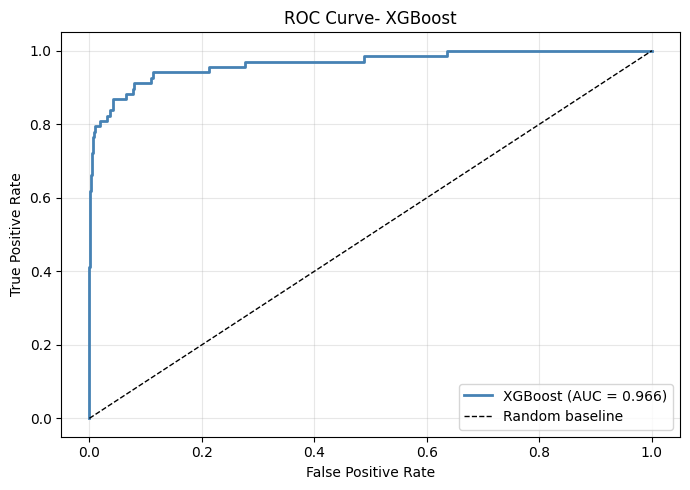

In [44]:
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
auc = roc_auc_score(y_test, y_prob_xgb)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'XGBoost (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve- XGBoost')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### comparision table for all models

In [45]:
results_df = pd.DataFrame(results).drop_duplicates(subset='Model', keep='last').reset_index(drop=True)

results_df_display = results_df.copy()
results_df_display['Accuracy'] = results_df_display['Accuracy'].map('{:.1f}%'.format)
results_df_display['Precision'] = results_df_display['Precision'].map('{:.3f}'.format)
results_df_display['Recall'] = results_df_display['Recall'].map('{:.3f}'.format)
results_df_display['F1'] = results_df_display['F1'].map('{:.3f}'.format)
results_df_display['ROC-AUC'] = results_df_display['ROC-AUC'].map('{:.3f}'.format)

display(results_df_display)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Dummy Classifier,96.6%,0.000,0.000,0.000,0.500
1,Logistic Regression (no SMOTE),96.8%,0.600,0.132,0.217,0.901
2,Logistic Regression (SMOTE),84.4%,0.153,0.794,0.257,0.895
3,Random Forest (SMOTE),95.8%,0.426,0.721,0.536,0.958
4,XGBoost (threshold=0.5),97.5%,0.591,0.809,0.683,0.966


## Modeling Summary

1. The Dummy Classifier achieved 96.6% accuracy but failed to identify any failures. This confirmed that accuracy is misleading for this dataset.

2. Logistic Regression without SMOTE achieved high accuracy but only 13.2% recall, showing that the model struggled with the minority class.

3. Applying SMOTE increased recall to 79.4%, but precision dropped significantly. The model detected more failures but generated many false alarms.

4. Random Forest with SMOTE improved the balance between precision and recall, achieving an F1 score of 0.536. This suggests that non-linear models fit the data better than a simple linear boundary.

5. XGBoost with class weighting produced the best overall performance, achieving 80.9% recall, 59.1% precision, an F1 score of 0.683, and ROC-AUC of 0.966.

Final model: XGBoost with class weighting.

## feature engineering

2 new features identified from eda-

    1. Power= Rotational speed x Torque
    
    2. Temp_diff= Process Temperature - Air Temperature (strong linear correlation)

In [46]:
df_clean['Power'] = df_clean['Rotational speed [rpm]'] * df_clean['Torque [Nm]']
df_clean['Temp_diff'] = df_clean['Process temperature [K]'] - df_clean['Air temperature [K]']

engineered_cols = X_full.columns.tolist() + ['Power', 'Temp_diff']

X_train_eng = X_train_full.copy()
X_train_eng['Power'] = X_train_full['Rotational speed [rpm]'] * X_train_full['Torque [Nm]']
X_train_eng['Temp_diff'] = X_train_full['Process temperature [K]'] - X_train_full['Air temperature [K]']

X_test_eng = X_test_full.copy()
X_test_eng['Power'] = X_test_full['Rotational speed [rpm]'] * X_test_full['Torque [Nm]']
X_test_eng['Temp_diff'] = X_test_full['Process temperature [K]'] - X_test_full['Air temperature [K]']

clean_names_eng = {col: col.replace('[', '').replace(']', '').replace('<', '').strip()
                   for col in X_train_eng.columns}

X_train_eng = X_train_eng.rename(columns=clean_names_eng)
X_test_eng = X_test_eng.rename(columns=clean_names_eng)

print("Engineered feature columns:")
print(X_train_eng.columns.tolist())
print("\nX_train_eng shape:", X_train_eng.shape)
print("X_test_eng shape: ", X_test_eng.shape)

Engineered feature columns:
['Type', 'Air temperature K', 'Process temperature K', 'Rotational speed rpm', 'Torque Nm', 'Tool wear min', 'Power', 'Temp_diff']

X_train_eng shape: (8000, 8)
X_test_eng shape:  (2000, 8)


In [47]:
xgb_eng = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    eval_metric='logloss',
    scale_pos_weight=scale,
    random_state=42,
    n_jobs=-1
)
xgb_eng.fit(X_train_eng, y_train)

y_prob_eng = xgb_eng.predict_proba(X_test_eng)[:, 1]
y_pred_eng = (y_prob_eng >= 0.5).astype(int)

print("XGBoost — Engineered Features")
print(classification_report(y_test, y_pred_eng, target_names=['No Failure', 'Failure']))

eng_metrics = {
    'Precision': round(precision_score(y_test, y_pred_eng, zero_division=0), 3),
    'Recall':    round(recall_score(y_test, y_pred_eng), 3),
    'F1':        round(f1_score(y_test, y_pred_eng), 3),
    'ROC-AUC':   round(roc_auc_score(y_test, y_prob_eng), 3),
}
orig_metrics = {
    'Precision': round(precision_score(y_test, y_pred_xgb_05, zero_division=0), 3),
    'Recall':    round(recall_score(y_test, y_pred_xgb_05), 3),
    'F1':        round(f1_score(y_test, y_pred_xgb_05), 3),
    'ROC-AUC':   round(roc_auc_score(y_test, y_prob_xgb), 3),
}

print("\nOriginal features:", orig_metrics)
print("Engineered features:", eng_metrics)

XGBoost — Engineered Features
              precision    recall  f1-score   support

  No Failure       0.99      0.98      0.99      1932
     Failure       0.63      0.84      0.72        68

    accuracy                           0.98      2000
   macro avg       0.81      0.91      0.85      2000
weighted avg       0.98      0.98      0.98      2000


Original features: {'Precision': 0.591, 'Recall': 0.809, 'F1': 0.683, 'ROC-AUC': 0.966}
Engineered features: {'Precision': 0.626, 'Recall': 0.838, 'F1': 0.717, 'ROC-AUC': 0.978}


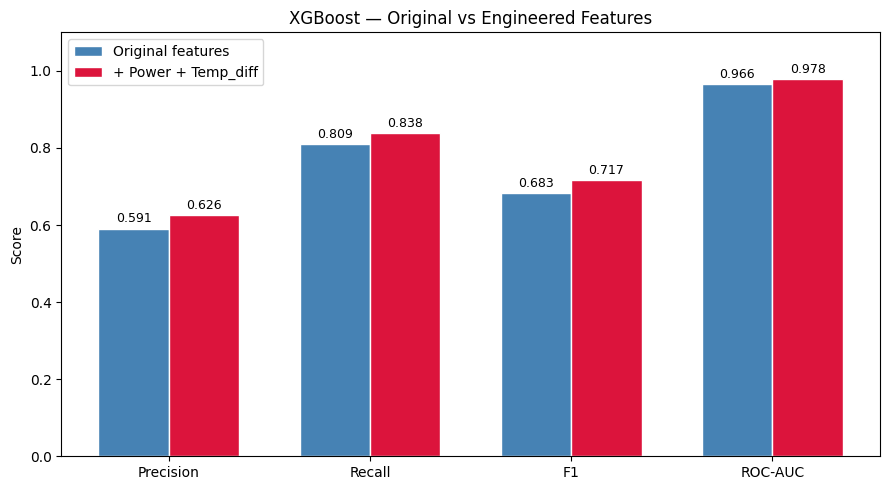

In [48]:
metrics = ['Precision', 'Recall', 'F1', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.35

orig_vals = [orig_metrics[m] for m in metrics]
eng_vals  = [eng_metrics[m]  for m in metrics]

fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(x - width/2, orig_vals, width,
               label='Original features', color='steelblue', edgecolor='white')
bars2 = ax.bar(x + width/2, eng_vals, width,
               label='+ Power + Temp_diff', color='crimson', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('XGBoost — Original vs Engineered Features')
ax.legend()
plt.tight_layout()
plt.show()

slight improvememnt in performance across all metrics. confirms eda hypothesis

## SHAP analysis:

to see which features were most important in the predictions

In [49]:
best_model = xgb_eng
X_test_shap = X_test_eng

explainer = shap.Explainer(best_model)
shap_values = explainer(X_test_shap)

print("SHAP values computed.")
print("Shape:", shap_values.shape)

SHAP values computed.
Shape: (2000, 8)


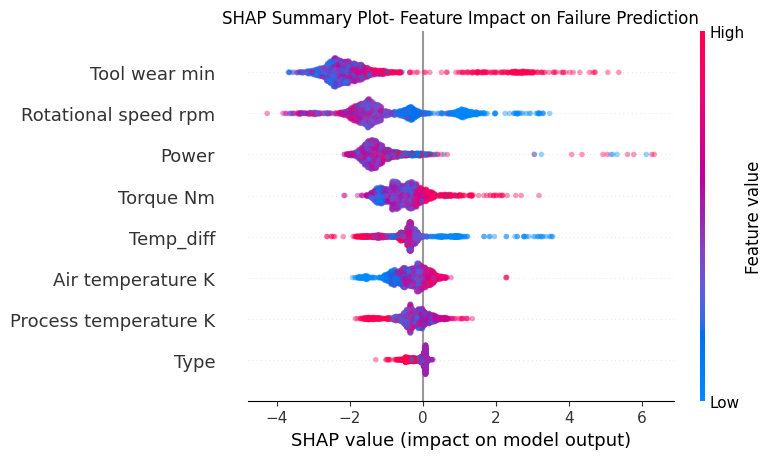

In [50]:
plt.figure()
shap.summary_plot(shap_values, X_test_shap, show=False, alpha=0.4)
plt.title('SHAP Summary Plot- Feature Impact on Failure Prediction')
plt.tight_layout()
plt.show()

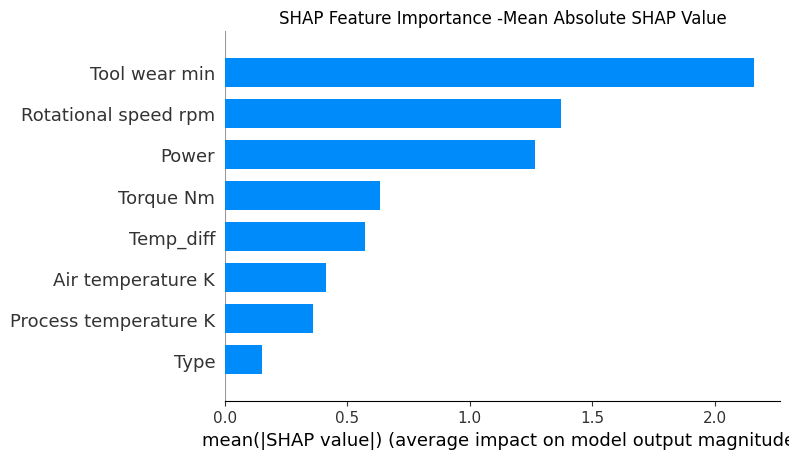

In [51]:
plt.figure()
shap.summary_plot(shap_values, X_test_shap, plot_type='bar', show=False)
plt.title('SHAP Feature Importance -Mean Absolute SHAP Value')
plt.tight_layout()
plt.show()

waterfall plot on a single true failure prediction

Showing prediction for test row 17
Actual: 1, Predicted: 1


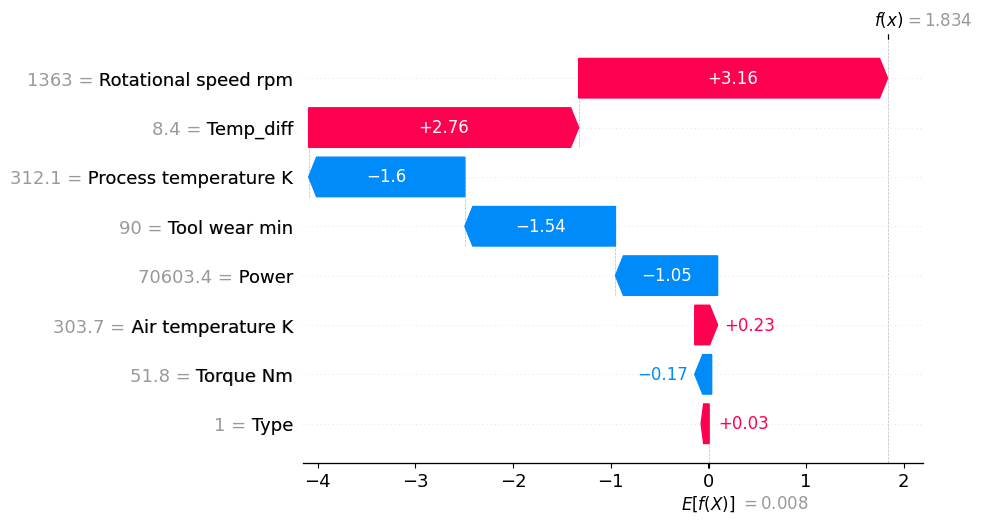

In [52]:
y_pred_final = (best_model.predict_proba(X_test_shap)[:, 1] >= 0.5).astype(int)
y_test_arr = y_test.values

true_positive_idx = np.where((y_pred_final == 1) & (y_test_arr == 1))[0][0]
print(f"Showing prediction for test row {true_positive_idx}")
print(f"Actual: {y_test_arr[true_positive_idx]}, Predicted: {y_pred_final[true_positive_idx]}")

shap.waterfall_plot(shap_values[true_positive_idx])

tool wear is by far the most important feature in failure prediction.

rotational speed and torque are 2nd and 3rd. temp features and type are least important. the engineered features have clear importace.

the failure prediction in waterfsll plot is consistent with a heat dissipation (HDF) failure- trigerred by abnormally low temperature differential and a low rotational speed. confirms that this pattern was learnt by the model without being expicitly told about it (no data leakage)

## Project Summary

**Dataset:** AI4I 2020 Predictive Maintenance (10,000 records, 3.4% failure rate)

**Objective:** Predict machine failures while maximizing recall, since missing a failure is more costly than raising a false alarm.

### Pipeline

* Removed ID columns and leakage features
* Encoded machine type (L, M, H)
* Performed an 80/20 stratified train-test split
* Applied SMOTE for Logistic Regression and Random Forest
* Used class weighting for XGBoost
* Created additional features: Power (Torque × RPM) and Temperature Difference

### Final Model

XGBoost (`n_estimators=200`, `max_depth=4`, `learning_rate=0.1`, `scale_pos_weight=28`)

| Metric    | Original Features | Engineered Features |
| --------- | ----------------- | ------------------- |
| Precision | 0.591             | 0.626               |
| Recall    | 0.809             | 0.838               |
| F1 Score  | 0.683             | 0.717               |
| ROC-AUC   | 0.966             | 0.978               |

### SHAP Insights

* Tool wear was the most important feature.
* Lower rotational speed increased failure risk.
* The engineered Power feature ranked among the top contributors.
* Temperature-related features had relatively low impact.

In [53]:
import pickle
import os

with open('app/model/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_eng, f)

feature_names = X_train_eng.columns.tolist()
with open('app/model/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

print("Saved model and feature names")
print("Features:", feature_names)

Saved model and feature names
Features: ['Type', 'Air temperature K', 'Process temperature K', 'Rotational speed rpm', 'Torque Nm', 'Tool wear min', 'Power', 'Temp_diff']
